In [1]:
import yfinance as yf
from fredapi import Fred
import pandas as pd
import pandas_datareader.data as web
import matplotlib.pyplot as plt
import numpy as np
import os

In [2]:
start_date = "2022-12-29"
end_date = "2023-12-31"

ticker = "SPTL"

# SPTL-ETF DATA
sptl = yf.download(ticker, start=start_date, end=end_date)
sptl.index = pd.to_datetime(sptl.index, format='%Y-%m-%d')
sptl.columns = sptl.columns.droplevel(1)
sptl.rename_axis(None, axis=1, inplace=True)
sptl.drop(columns=["Open"], inplace=True)

# Initital Price --> For ARIMAX signal generation
initial_price = sptl['Close'].iloc[0]

# EFFR DATA
fred = Fred(api_key="aa5b83460620af29578dfc123ecd2a1f")
effr_series = fred.get_series("EFFR", observation_start=start_date, observation_end=end_date)
effr_data = pd.DataFrame(effr_series, columns=["rf_annual"])
effr_data["rf_annual"] = (effr_data["rf_annual"] / 100.0)
effr_data.index = pd.to_datetime(effr_data.index, format='%Y-%d-%m')
effr_data["rf_annual"] = effr_data["rf_annual"].ffill()


# Merging SPTL-ETF and EFFR Data
merged_df = pd.merge(sptl, effr_data, left_index=True, right_index=True, how='left')

# Creating Daily EFFR Rate - Taken as the Daily Risk-free Rate
merged_df['rf_daily'] = merged_df['rf_annual'] / 252.0

# Daily Returns & Excess SPTL Returns
merged_df['returns'] = merged_df['Close'].pct_change()
merged_df['diff_returns'] = merged_df['Close'].diff()
merged_df['excess_returns'] = merged_df['returns'] - merged_df['rf_daily']

merged_df.dropna(inplace=True)
merged_df.drop(['High', 'Low', 'Volume'], axis=1, inplace=True)
# Method 1: drop by index label
merged_df.drop(merged_df.index[0], inplace=True)
merged_df

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


,Close,rf_annual,rf_daily,returns,diff_returns,excess_returns
Date,,,,,,
2023-01-03,25.953474,0.0433,0.000172,0.017224,0.439442,0.017052
2023-01-04,26.278664,0.0433,0.000172,0.012530,0.325190,0.012358
2023-01-05,26.384129,0.0433,0.000172,0.004013,0.105465,0.003842
2023-01-06,26.841146,0.0433,0.000172,0.017322,0.457018,0.017150
2023-01-09,26.972979,0.0433,0.000172,0.004912,0.131832,0.004740
...,...,...,...,...,...,...
2023-12-22,26.246447,0.0533,0.000212,-0.003104,-0.081734,-0.003316
2023-12-26,26.291853,0.0533,0.000212,0.001730,0.045406,0.001518
2023-12-27,26.736862,0.0533,0.000212,0.016926,0.445009,0.016714


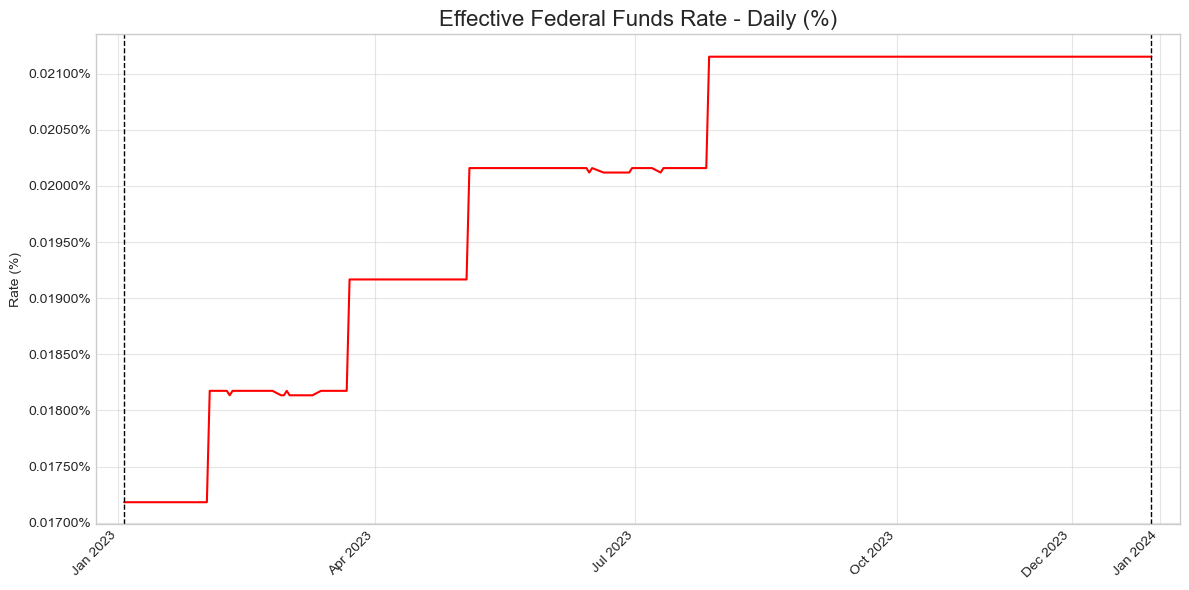

In [3]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
from matplotlib.ticker import PercentFormatter
plt.style.use('seaborn-v0_8-whitegrid')


df = merged_df.copy()
# First & last date in the series
start = df.index.min()   # 2023-01-03
end = df.index.max()   # 2023-12-29
pad = pd.Timedelta(days=10)

# 1) EFFR Daily

fig1, ax1 = plt.subplots(figsize=(12, 6))
# Use a step plot so that the rate remains constant until a change:
ax1.plot(df.index, df['rf_daily'], color='red', linewidth=1.5)
ax1.set_title('Effective Federal Funds Rate - Daily (%)', fontsize=16)
ax1.set_ylabel('Rate (%)', fontsize=10)
ax1.yaxis.set_major_formatter(PercentFormatter(1.0))
ax1.grid(alpha=0.5)

# Formatting x-axis (dates)
ax1.set_xlim(start - pad, end + pad)
ax1.xaxis.set_major_locator(
    mdates.MonthLocator(bymonth=[1,4,7,10,12])
)
ax1.xaxis.set_major_formatter(
    mdates.DateFormatter('%b %Y')
)
plt.setp(ax1.get_xticklabels(), rotation=45, ha='right')

# --- Vertical dashed lines at the endpoints ---
ax1.axvline(start, color='black', linestyle='--', linewidth=1)
ax1.axvline(end,   color='black', linestyle='--', linewidth=1)


plt.tight_layout()
plt.show()

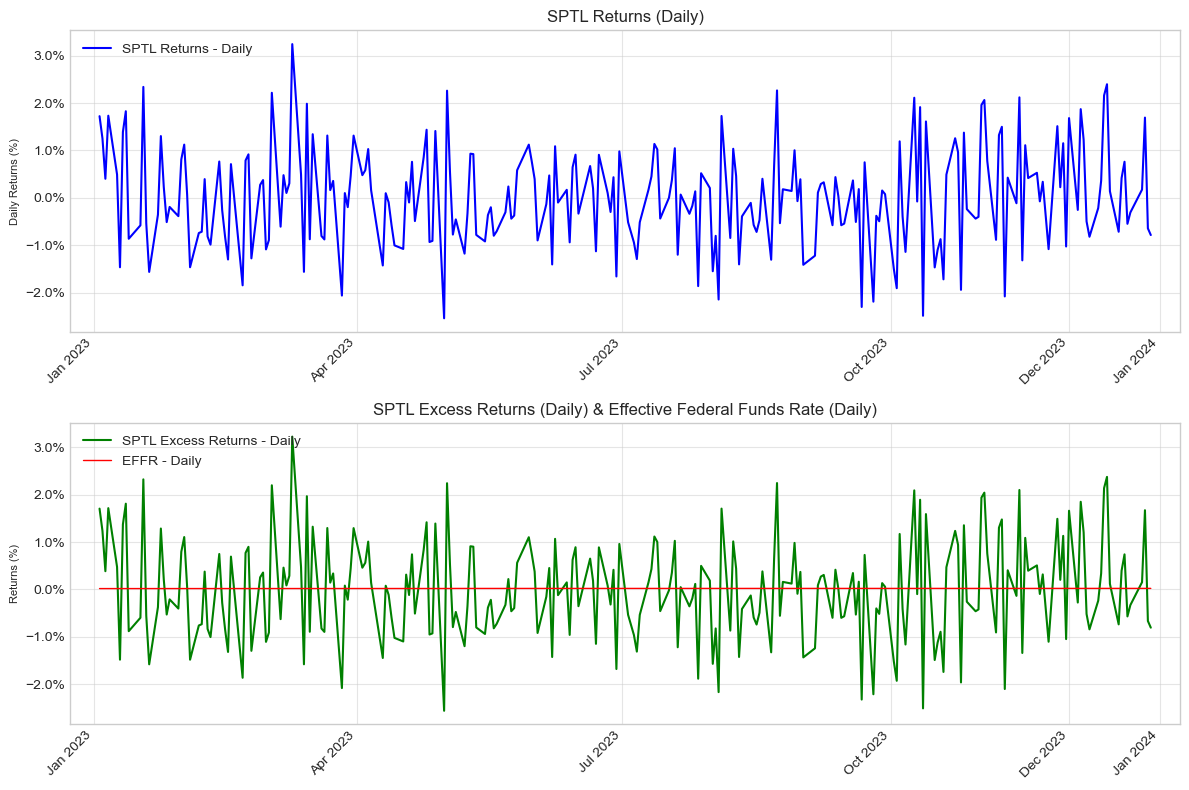

In [4]:
# SPTL Returns

fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# 1) SPTL Daily Returns
ax[0].plot(df.index, df['returns'], color='blue', linewidth=1.5,
           label='SPTL Returns - Daily')

ax[0].set_title('SPTL Returns (Daily)', fontsize = 12)
ax[0].set_ylabel('Daily Returns (%)', fontsize=8)
ax[0].yaxis.set_major_formatter(PercentFormatter(1.0))
ax[0].legend(loc='upper left')
ax[0].grid(alpha=0.5)


ax[0].tick_params(axis='x', labelbottom=True)

ax[0].set_xlim(start - pad, end + pad)
ax[0].xaxis.set_major_locator(
    mdates.MonthLocator(bymonth=[1,4,7,10,12])
)
ax[0].xaxis.set_major_formatter(
    mdates.DateFormatter('%b %Y')
)
plt.setp(ax[0].get_xticklabels(), rotation=45, ha='right')


# 2) SPTL Excess Returns with daily effr overlay
ax[1].plot(df.index, df['excess_returns'], color='green', linewidth=1.5,
           label='SPTL Excess Returns - Daily')
ax[1].plot(df.index, df['rf_daily'], color='red', linewidth=1,
           label='EFFR - Daily')

ax[1].set_title('SPTL Excess Returns (Daily) & Effective Federal Funds Rate (Daily)', fontsize=12)
ax[1].set_ylabel('Returns (%)', fontsize=8)
ax[1].yaxis.set_major_formatter(PercentFormatter(1.0))
ax[1].legend(loc='upper left')
ax[1].grid(alpha=0.5)

ax[1].set_xlim(start - pad, end + pad)
ax[1].xaxis.set_major_locator(
    mdates.MonthLocator(bymonth=[1,4,7,10,12])
)
ax[1].xaxis.set_major_formatter(
    mdates.DateFormatter('%b %Y')
)
plt.setp(ax[1].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()
